In [1]:
import asyncio
import logging
from pathlib import Path
import sys
import os
import pandas as pd
import torch

import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent))

from src.utils.llm_client import YandexGPTClient
from src.detector.llm_reasoner import LLMReasoner
from src.judges.judge_d1 import JudgeD1
from src.judges.judge_d2 import JudgeD2
from bert_token_scorer import AIDetectorInference
from src.detector.detectgpt_lightweight import LightweightDetectGPT

import warnings
warnings.filterwarnings("ignore")

/home/jupyter/.local/lib/python3.10/site-packages/transformers/utils/hub.py:127: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [2]:
logging.basicConfig(level=logging.ERROR)

In [4]:
df = pd.read_csv(os.path.join(DATAPATH, 'final_dataset.csv'))
df

,article_id,chunk_id,text,label,ai_spans_json,ai_span_start_char,ai_span_end_char,ai_span_start_word,ai_span_end_word,ai_fraction,has_mixed_content,strategy,source_model,judge_semantic_score,judge_complexity_score,judge_avg,word_count,char_count,chunk_index,total_chunks,original_chunk_id,created_at
0,modernizatsiya-strany-i-nekotorye-problemy-gum...,modernizatsiya-strany-i-nekotorye-problemy-gum...,ОБЩАЯ ПЕДАГОГИКА. ИСТОРИЯ ПЕДАГОГИКИ И ОБРАЗОВ...,0,[],NaN,NaN,NaN,NaN,0.0,False,original,Human,NaN,NaN,NaN,865,7103,0,2,modernizatsiya-strany-i-nekotorye-problemy-gum...,2026-03-31T10:50:19.251314
1,modernizatsiya-strany-i-nekotorye-problemy-gum...,modernizatsiya-strany-i-nekotorye-problemy-gum...,"По сути, сфера смыслов оказывается в фокусе на...",0,[],NaN,NaN,NaN,NaN,0.0,False,original,Human,NaN,NaN,NaN,813,6993,1,2,modernizatsiya-strany-i-nekotorye-problemy-gum...,2026-03-31T10:50:19.251314
2,prak-tiki-tsivilizatsionnogo-realizma,prak-tiki-tsivilizatsionnogo-realizma_chunk0_h...,ПРАКТИКИ ЦИВИЛИЗАЦИОННОГО РЕАЛИЗМА Аннотация В...,0,[],NaN,NaN,NaN,NaN,0.0,False,original,Human,NaN,NaN,NaN,698,5928,0,5,prak-tiki-tsivilizatsionnogo-realizma_chunk0_h...,2026-03-31T10:50:19.562318
3,prak-tiki-tsivilizatsionnogo-realizma,prak-tiki-tsivilizatsionnogo-realizma_chunk1_h...,"""Евразийский смысл — самоуглубляющаяся структу...",0,[],NaN,NaN,NaN,NaN,0.0,False,original,Human,NaN,NaN,NaN,699,6031,1,5,prak-tiki-tsivilizatsionnogo-realizma_chunk1_h...,2026-03-31T10:50:19.562318
4,prak-tiki-tsivilizatsionnogo-realizma,prak-tiki-tsivilizatsionnogo-realizma_chunk2_h...,В практическом плане представители российского...,0,[],NaN,NaN,NaN,NaN,0.0,False,original,Human,NaN,NaN,NaN,953,8165,2,5,prak-tiki-tsivilizatsionnogo-realizma_chunk2_h...,2026-03-31T10:50:19.562318
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3455,kategorii-bozhestvennoe-i-svyaschennoe-v-susch...,kategorii-bozhestvennoe-i-svyaschennoe-v-susch...,А. В. Кольцов. Категории «божественного» и «св...,1,"[[0, 5430]]",0.0,5430.0,0.0,674.0,1.0,False,back_translation,Yandex_gpt://b1gv4m4vdn58mat55ggl/yandexgpt-5-...,4.0,4.0,4.0,674,5430,0,4,kategorii-bozhestvennoe-i-svyaschennoe-v-susch...,2026-03-31T13:48:15.812460
3456,kategorii-bozhestvennoe-i-svyaschennoe-v-susch...,kategorii-bozhestvennoe-i-svyaschennoe-v-susch...,Тем не менее было бы ошибкой полностью отрицат...,1,"[[0, 6724]]",0.0,6724.0,0.0,804.0,1.0,False,back_translation,Yandex_gpt://b1gv4m4vdn58mat55ggl/yandexgpt-5-...,4.0,4.0,4.0,804,6724,1,4,kategorii-bozhestvennoe-i-svyaschennoe-v-susch...,2026-03-31T13:49:17.465399
3457,arheologicheskie-raboty-tamanskoy-ekspeditsii-...,arheologicheskie-raboty-tamanskoy-ekspeditsii-...,В 1930 году сотрудники Таманской экспедиции Го...,1,"[[0, 5806]]",0.0,5806.0,0.0,785.0,1.0,False,back_translation,Yandex_gpt://b1gv4m4vdn58mat55ggl/yandexgpt-5-...,5.0,5.0,5.0,785,5806,3,7,arheologicheskie-raboty-tamanskoy-ekspeditsii-...,2026-03-31T13:50:05.384080
3458,rabota-politologa-po-strategicheskomu-planirov...,rabota-politologa-po-strategicheskomu-planirov...,Некоторые краткие выводы из исследования.\n\n1...,1,"[[0, 5409]]",0.0,5409.0,0.0,705.0,1.0,False,back_translation,Yandex_gpt://b1gv4m4vdn58mat55ggl/yandexgpt-5-...,4.0,3.0,3.5,705,5409,8,10,rabota-politologa-po-strategicheskomu-planirov...,2026-03-31T13:50:53.127274


In [5]:
df[df.has_mixed_content == True]

,article_id,chunk_id,text,label,ai_spans_json,ai_span_start_char,ai_span_end_char,ai_span_start_word,ai_span_end_word,ai_fraction,has_mixed_content,strategy,source_model,judge_semantic_score,judge_complexity_score,judge_avg,word_count,char_count,chunk_index,total_chunks,original_chunk_id,created_at
829,role-of-business-subjects-in-democratization-p...,role-of-business-subjects-in-democratization-p...,"Социологические, философские и политологически...",2,"[[2653, 4302]]",2653.0,4302.0,340.0,567.0,0.400,True,partial_continuation,Yandex_gpt://b1gv4m4vdn58mat55ggl/yandexgpt-5-...,4.0,3.0,3.5,567,4302,0,6,role-of-business-subjects-in-democratization-p...,2026-03-31T10:51:40.387190
833,konstitutsionnoe-pravo-konstitutsionnyy-sudebn...,konstitutsionnoe-pravo-konstitutsionnyy-sudebn...,"Как представляется, современному казахстанском...",2,"[[2772, 4031]]",2772.0,4031.0,334.0,487.0,0.210,True,partial_middle_insert,Yandex_gpt://b1gv4m4vdn58mat55ggl/yandexgpt-5-...,5.0,4.0,4.5,729,6020,1,4,konstitutsionnoe-pravo-konstitutsionnyy-sudebn...,2026-03-31T10:51:45.251109
834,politicheskaya-nauka-i-politicheskoe-obrazovan...,politicheskaya-nauka-i-politicheskoe-obrazovan...,О необходимости дальнейшего развития марксизма...,2,"[[1390, 2895]]",1390.0,2895.0,172.0,362.0,0.324,True,partial_middle_insert,Yandex_gpt://b1gv4m4vdn58mat55ggl/yandexgpt-5-...,5.0,4.0,4.5,586,4808,2,4,politicheskaya-nauka-i-politicheskoe-obrazovan...,2026-03-31T10:51:47.911586
835,konstitutsionnoe-pravo-konstitutsionnyy-sudebn...,konstitutsionnoe-pravo-konstitutsionnyy-sudebn...,"Как представляется, современному казахстанском...",2,"[[4309, 5648]]",4309.0,5648.0,524.0,682.0,0.232,True,partial_continuation,Yandex_gpt://b1gv4m4vdn58mat55ggl/yandexgpt-5-...,5.0,2.0,3.5,682,5648,1,4,konstitutsionnoe-pravo-konstitutsionnyy-sudebn...,2026-03-31T10:51:49.351155
837,politicheskaya-nauka-i-politicheskoe-obrazovan...,politicheskaya-nauka-i-politicheskoe-obrazovan...,О необходимости дальнейшего развития марксизма...,2,"[[2367, 3175]]",2367.0,3175.0,289.0,390.0,0.259,True,partial_continuation,Yandex_gpt://b1gv4m4vdn58mat55ggl/yandexgpt-5-...,4.0,3.0,3.5,390,3175,2,4,politicheskaya-nauka-i-politicheskoe-obrazovan...,2026-03-31T10:51:58.451102
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3364,religiovedenie-v-sovremennoy-rossii-vzglyad-iz...,religiovedenie-v-sovremennoy-rossii-vzglyad-iz...,Постепенно проникающая во все сферы производст...,2,"[[1965, 3392]]",1965.0,3392.0,241.0,418.0,0.252,True,partial_middle_insert,Yandex_gpt://b1gv4m4vdn58mat55ggl/yandexgpt-5-...,0.0,3.0,1.5,703,5578,3,8,religiovedenie-v-sovremennoy-rossii-vzglyad-iz...,2026-03-31T12:57:55.324413
3366,pravo-na-sudebnuyu-zaschitu-i-pravo-na-spraved...,pravo-na-sudebnuyu-zaschitu-i-pravo-na-spraved...,Органические и институциональные элементы связ...,2,"[[2211, 2880]]",2211.0,2880.0,255.0,336.0,0.241,True,partial_continuation,Yandex_gpt://b1gv4m4vdn58mat55ggl/yandexgpt-5-...,5.0,3.0,4.0,336,2880,3,5,pravo-na-sudebnuyu-zaschitu-i-pravo-na-spraved...,2026-03-31T12:57:59.538307
3367,pravo-na-sudebnuyu-zaschitu-i-pravo-na-spraved...,pravo-na-sudebnuyu-zaschitu-i-pravo-na-spraved...,Органические и институциональные элементы связ...,2,"[[1435, 2693]]",1435.0,2693.0,167.0,312.0,0.294,True,partial_middle_insert,Yandex_gpt://b1gv4m4vdn58mat55ggl/yandexgpt-5-...,5.0,3.0,4.0,493,4054,3,5,pravo-na-sudebnuyu-zaschitu-i-pravo-na-spraved...,2026-03-31T12:57:59.734501
3370,pravo-na-sudebnuyu-zaschitu-i-pravo-na-spraved...,pravo-na-sudebnuyu-zaschitu-i-pravo-na-spraved...,"М., 2003. С. 48. общие для множества стран. Оч...",2,"[[1248, 2321]]",1248.0,2321.0,155.0,281.0,0.296,True,partial_middle_insert,Yandex_gpt://b1gv4m4vdn58mat55ggl/yandexgpt-5-...,5.0,3.0,4.0,425,3403,4,5,pravo-na-sudebnuyu-zaschitu-i-pravo-na-spraved...,2026-03-31T12:58:05.631149


In [6]:
df.iloc[834]['text']

'О необходимости дальнейшего развития марксизма и перспективах теории Маркса в наше время говорил доктор философских наук, профессор Г.А. Багатурия. Основоположники марксизма создали некоторую новую науку, аспекты которой образуют определенное органическое единство. Предмет этой науки можно определить как законы формационного преобразования общества. В эпоху возникновения этого нового научного направления главным и актуальным для его основоположников было предстоящее коммунистическое преобразование общества. Но созданное ими диалектико-материалистическое понимание истории, с одной стороны, давало ключ к пониманию закономерностей перехода от одной общественной формации к другой в предшествующей истории, а с другой — явилось предпосылкой для разработки общей теории формационных преобразований общества в дальнейшем развитии человеческого общества Одна из закономерностей развития науки — это ее обобщение. Подобная закономерность должна действовать и в истории марксизма — и в плане разработ

In [7]:
llm_client = YandexGPTClient(api_key=API_KEY, folder_id=FOLDER_ID)

In [8]:
raw = await llm_client.generate(system_text='Напиши начало и конец вводной фразы, каждый в несколько предложений. Выведи просто текст, без дополнений, обозначений и переносов, а вводный текст вставь в середину', user_text='Представляется, что анализируемая статья ГК РФ ограничивает возможности потерпевших по получению возмещения понесенного вреда, так как устанавливает безусловное основание для прекращения ответственности субсидиарных должников с момента достижения деликвентом совершеннолетия')
raw

'При рассмотрении вопросов возмещения вреда, причинённого действиями несовершеннолетних, особое внимание привлекает статья ГК РФ, регулирующая ответственность субсидиарных должников. Представляется, что анализируемая статья ГК РФ ограничивает возможности потерпевших по получению возмещения понесённого вреда, так как устанавливает безусловное основание для прекращения ответственности субсидиарных должников с момента достижения деликвентом совершеннолетия. Это положение вызывает вопросы относительно защиты прав потерпевших и требует детального анализа с точки зрения справедливости и эффективности правового регулирования.'

In [9]:
mixed_text = df.iloc[834]['text']

### BERT testing

In [10]:
import numpy as np
from collections import Counter
from typing import Dict, List, Any
import pandas as pd
import torch
from IPython.display import display, HTML

def analyze_bert_windows(
    text: str,
    detector,
    min_confidence: float = 0.1,
    show_all_tokens: bool = False,
    max_display_tokens: int = None  # None = все токены
) -> Dict[str, Any]:
    """
    Детальный анализ работы оконного метода BERT.
    Показывает:
    - как разбивается текст на окна
    - какие токены в каждом окне получили AI-метку
    - итоговое голосование по каждому токену
    - финальные спаны
    """
    
    encoding = detector._tokenize_with_offsets(text)
    full_input_ids = encoding["input_ids"][0].tolist()
    full_offset_mapping = encoding["offset_mapping"][0].numpy()
    total_tokens = len(full_input_ids)

    all_tokens = detector.tokenizer.convert_ids_to_tokens(full_input_ids)

    token_votes_ai = Counter()
    token_votes_total = Counter()
    token_avg_confidence = Counter()

    windows_info = []
    
    print("=" * 80)
    print("АНАЛИЗ ОКОННОГО МЕТОДА BERT")
    print("=" * 80)
    print(f"Длина текста: {len(text)} символов")
    print(f"Токенов всего: {total_tokens}")
    print(f"Размер окна: {detector.window_size} токенов")
    print(f"Шаг (stride): {detector.stride} токенов")
    print(f"Перекрытие: {detector.window_size - detector.stride} токенов")
    
    num_windows = 0
    for start in range(0, max(1, total_tokens - detector.window_size + detector.stride), detector.stride):
        num_windows += 1
    print(f"Всего окон: {num_windows}")
    print("=" * 80)

    window_idx = 0
    for start in range(0, max(1, total_tokens - detector.window_size + detector.stride), detector.stride):
        end = min(start + detector.window_size, total_tokens)
        window_idx += 1

        window_ids = full_input_ids[start:end]
        window_tokens = all_tokens[start:end]
        window_mask = [1] * len(window_ids)

        if len(window_ids) < detector.window_size:
            pad_len = detector.window_size - len(window_ids)
            window_ids = window_ids + [detector.tokenizer.pad_token_id] * pad_len
            window_mask = window_mask + [0] * pad_len
        
        input_ids = torch.tensor([window_ids])
        attention_mask = torch.tensor([window_mask])

        preds, probs = detector._predict_window(input_ids, attention_mask)
        
        actual_len = min(detector.window_size, end - start)

        ai_tokens_in_window = []
        human_tokens_in_window = []
        
        for i in range(actual_len):
            token_idx = start + i
            label = detector.id2label.get(preds[i], "O")
            confidence = probs[i][preds[i]]
            
            token_votes_total[token_idx] += 1
            token_avg_confidence[token_idx] += confidence
            
            if label in detector.ai_labels and confidence >= min_confidence:
                token_votes_ai[token_idx] += 1
                ai_tokens_in_window.append({
                    'pos': i,
                    'token': window_tokens[i],
                    'label': label,
                    'confidence': confidence,
                    'char_start': full_offset_mapping[token_idx][0],
                    'char_end': full_offset_mapping[token_idx][1]
                })
            elif not show_all_tokens:
                pass
            else:
                human_tokens_in_window.append({
                    'pos': i,
                    'token': window_tokens[i],
                    'label': label,
                    'confidence': confidence
                })

        window_info = {
            'window_num': window_idx,
            'token_range': f"[{start}:{end}]",
            'char_range': f"[{full_offset_mapping[start][0]}:{full_offset_mapping[end-1][1] if end <= total_tokens else full_offset_mapping[-1][1]}]",
            'text_preview': text[full_offset_mapping[start][0]:full_offset_mapping[min(end, total_tokens)-1][1]][:100],
            'num_ai_tokens': len(ai_tokens_in_window),
            'ai_ratio': len(ai_tokens_in_window) / actual_len if actual_len > 0 else 0,
            'ai_tokens': ai_tokens_in_window[:10]
        }
        windows_info.append(window_info)
    
    # ИСПРАВЛЕНИЕ 1: Используем DataFrame для вывода токенов
    print("\n" + "=" * 80)
    print("РЕЗУЛЬТАТЫ ГОЛОСОВАНИЯ ПО ТОКЕНАМ")
    print("=" * 80)
    
    token_results = []
    for idx in range(total_tokens):
        start_char, end_char = full_offset_mapping[idx]
        
        # Пропускаем спецтокены
        if start_char == 0 and end_char == 0:
            continue
        
        total_votes = token_votes_total.get(idx, 0)
        ai_votes = token_votes_ai.get(idx, 0)
        avg_conf = token_avg_confidence.get(idx, 0) / max(total_votes, 1)
        
        ai_ratio = ai_votes / max(total_votes, 1) * 100
        is_ai = ai_ratio > 50
        
        token_results.append({
            'Индекс': idx,
            'Токен': all_tokens[idx].replace('##', ''),
            'Нач.поз': start_char,
            'Кон.поз': end_char,
            'AI голосов': ai_votes,
            'Всего голосов': total_votes,
            '% AI': f"{ai_ratio:.1f}%",
            'Ср.conf': f"{avg_conf:.3f}",
            'Вердикт': "AI ✓" if is_ai else "O",
            'Текст': text[start_char:end_char][:50]
        })
    
    # Создаем DataFrame
    df = pd.DataFrame(token_results)
    
    # Фильтруем если нужно
    if not show_all_tokens:
        df_display = df[df['Вердикт'] == "AI ✓"]
        print(f"\nПоказаны только AI-токены ({len(df_display)} из {len(df)}).")
        print("Для показа всех токенов используйте show_all_tokens=True\n")
    else:
        df_display = df
    
    # ИСПРАВЛЕНИЕ 2: Красивый вывод без обрезания
    if len(df_display) > 0:
        if max_display_tokens is None:
            # Показываем все в скроллируемом окне
            with pd.option_context('display.max_rows', None, 'display.max_colwidth', 50):
                display(HTML(df_display.to_html()))
        else:
            # Постраничный вывод
            for i in range(0, len(df_display), max_display_tokens):
                print(f"\n--- Токены {i+1}-{min(i+max_display_tokens, len(df_display))} из {len(df_display)} ---\n")
                with pd.option_context('display.max_rows', max_display_tokens):
                    display(df_display.iloc[i:i+max_display_tokens])
                if i + max_display_tokens < len(df_display):
                    input("Нажмите Enter для продолжения...")
    else:
        print("Токены с меткой AI не найдены")

    print("\n" + "=" * 80)
    print("ФИНАЛЬНЫЕ AI-СПАНЫ")
    print("=" * 80)
    
    spans = detector.predict_spans_sliding_window(text, min_confidence=min_confidence)
    
    if not spans:
        print("AI-спаны не найдены.")
        suspicious = sorted(token_results, key=lambda x: float(x['% AI'].rstrip('%')), reverse=True)[:10]
        print("\nТоп-10 наиболее подозрительных токенов:")
        for t in suspicious:
            print(f"  [{t['Нач.поз']}:{t['Кон.поз']}] \"{t['Текст']}\" — AI-ratio: {t['% AI']}")
    else:
        for i, span in enumerate(spans):
            print(f"\nСпан #{i+1}:")
            print(f"  Позиция: [{span['start_char']}:{span['end_char']}]")
            print(f"  Токенов: {span['num_tokens']}")
            print(f"  Текст: \"{span['text'][:200]}{'...' if len(span['text']) > 200 else ''}\"")
            print(f"  Токены: {span['tokens_debug'][:10]}{'...' if len(span['tokens_debug']) > 10 else ''}")

            span_tokens = [t for t in token_results 
                          if t['Нач.поз'] >= span['start_char'] and t['Кон.поз'] <= span['end_char']]
            ai_confidences = [float(t['Ср.conf']) for t in span_tokens]
            if ai_confidences:
                print(f"  Средний confidence: {np.mean(ai_confidences):.3f}")
                print(f"  Медианный confidence: {np.median(ai_confidences):.3f}")

    print("\n" + "=" * 80)
    print("СВОДНАЯ СТАТИСТИКА")
    print("=" * 80)
    ai_token_count = sum(1 for t in token_results if t['Вердикт'] == "AI ✓")
    total_real_tokens = len(token_results)

    windows_ai_ratios = [w['ai_ratio'] for w in windows_info]
    
    print(f"Всего реальных токенов: {total_real_tokens}")
    print(f"AI-токенов (по голосованию): {ai_token_count} ({ai_token_count/total_real_tokens*100:.1f}%)")
    print(f"Human-токенов: {total_real_tokens - ai_token_count} ({(total_real_tokens-ai_token_count)/total_real_tokens*100:.1f}%)")
    print(f"Найдено спанов: {len(spans)}")
    print(f"Окон всего: {len(windows_info)}")
    print(f"Средний % AI-токенов в окне: {np.mean(windows_ai_ratios)*100:.1f}%")
    print(f"Разброс % AI по окнам: от {min(windows_ai_ratios)*100:.1f}% до {max(windows_ai_ratios)*100:.1f}%")
    
    return {
        'windows_info': windows_info,
        'token_results': token_results,
        'final_spans': spans,
        'summary': {
            'total_tokens': total_real_tokens,
            'ai_tokens': ai_token_count,
            'ai_ratio': ai_token_count / max(total_real_tokens, 1),
            'num_windows': len(windows_info),
            'num_spans': len(spans),
            'mean_ai_per_window': np.mean(windows_ai_ratios)
        }
    }

In [11]:
detector = AIDetectorInference(
    model_path=model_path,
    device='cuda',
    window_size=128,
    overlap_ratio=0.8
)

results = analyze_bert_windows(
    text=mixed_text,
    detector=detector,
    min_confidence=0.8,
    show_all_tokens=True
)

АНАЛИЗ ОКОННОГО МЕТОДА BERT
Длина текста: 4808 символов
Токенов всего: 1305
Размер окна: 128 токенов
Шаг (stride): 25 токенов
Перекрытие: 103 токенов
Всего окон: 49

РЕЗУЛЬТАТЫ ГОЛОСОВАНИЯ ПО ТОКЕНАМ


,Индекс,Токен,Нач.поз,Кон.поз,AI голосов,Всего голосов,% AI,Ср.conf,Вердикт,Текст
0,1,▁О,0,1,0,1,0.0%,1.000,O,О
1,2,▁необходимо,1,12,0,1,0.0%,0.999,O,необходимо
2,3,сти,12,15,0,1,0.0%,0.999,O,сти
3,4,▁да,15,18,0,1,0.0%,0.999,O,да
4,5,льней,18,23,0,1,0.0%,0.999,O,льней
5,6,шего,23,27,0,1,0.0%,0.999,O,шего
6,7,▁развити,27,35,0,1,0.0%,0.999,O,развити
7,8,я,35,36,0,1,0.0%,0.998,O,я
8,9,▁марк,36,41,0,1,0.0%,0.999,O,марк
9,10,с,41,42,0,1,0.0%,0.999,O,с



ФИНАЛЬНЫЕ AI-СПАНЫ

Спан #1:
  Позиция: [1704:2078]
  Токенов: 97
  Текст: "ей. По мнению докладчика, Фихте считает, что стремление к предельной личной свободе, понимаемой как атомарная «автономизация» личности, отражает ситуацию разорванной социокультурной коммуникации при о..."
  Токены: ['ей', '.', '▁По', '▁мне', 'нию', '▁доклад', 'чика', ',', '▁Фи', 'хте']...
  Средний confidence: 0.954
  Медианный confidence: 0.948

СВОДНАЯ СТАТИСТИКА
Всего реальных токенов: 1303
AI-токенов (по голосованию): 97 (7.4%)
Human-токенов: 1206 (92.6%)
Найдено спанов: 1
Окон всего: 49
Средний % AI-токенов в окне: 8.8%
Разброс % AI по окнам: от 0.0% до 100.0%


ПРОВЕРКА ДАННЫХ
Всего токенов в results: 1303
Диапазон индексов токенов: от 1 до 1303
Это должно быть ~1300, а не 4000!
Символов в тексте: 4808
Первый реальный токен: индекс 1
Пример первых 10 индексов: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


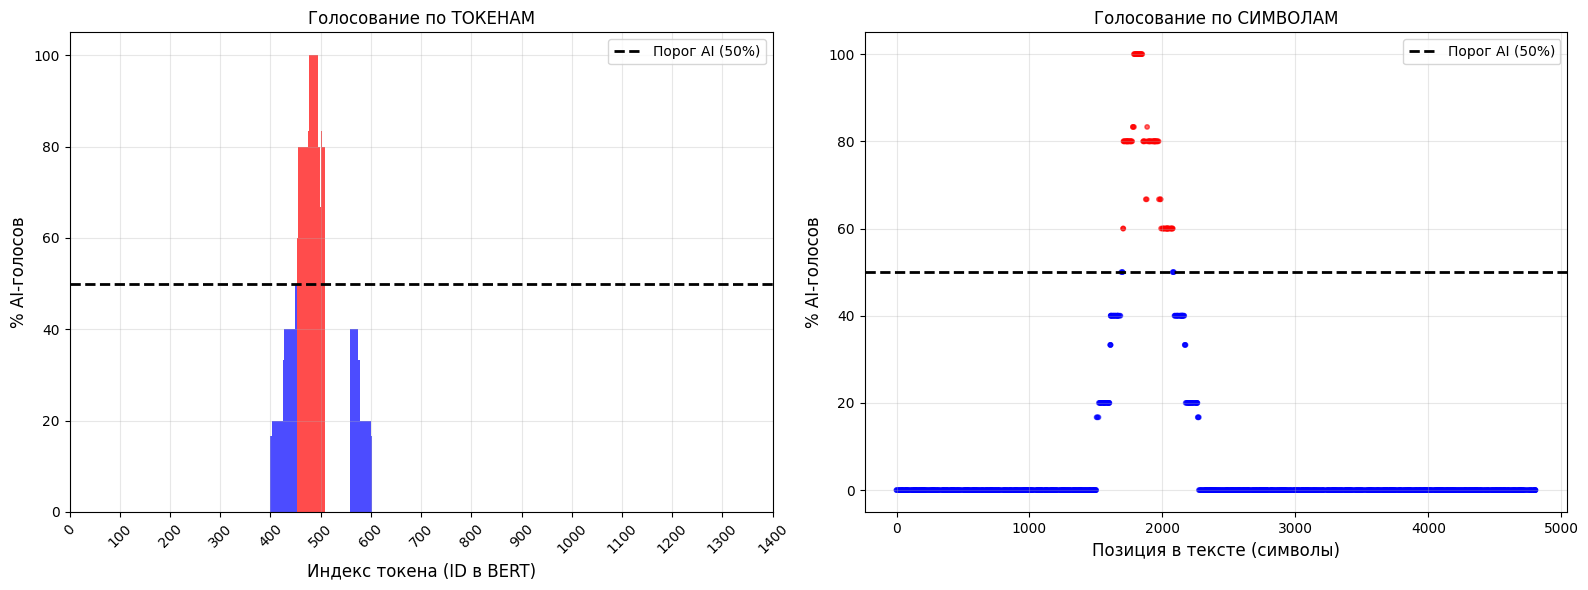


ТЕПЛОВАЯ КАРТА ОКОН (символьные диапазоны)
Окно  1 |··················································|   0.0% AI  [0:491]
Окно  2 |··················································|   0.0% AI  [89:586]
Окно  3 |··················································|   0.0% AI  [184:686]
Окно  4 |··················································|   0.0% AI  [278:772]
Окно  5 |··················································|   0.0% AI  [380:887]
Окно  6 |··················································|   0.0% AI  [471:974]
Окно  7 |··················································|   0.0% AI  [578:1069]
Окно  8 |··················································|   0.0% AI  [677:1162]
Окно  9 |··················································|   0.0% AI  [764:1256]
Окно 10 |··················································|   0.0% AI  [872:1345]
Окно 11 |··················································|   0.0% AI  [967:1428]
Окно 12 |···········································

In [12]:
# ПРАВИЛЬНАЯ ВИЗУАЛИЗАЦИЯ
token_results = results['token_results']

# Индексы токенов (должны быть от ~0 до ~1300)
positions = [t['Индекс'] for t in token_results]
ai_ratios = [float(t['% AI'].rstrip('%')) for t in token_results]

print("=" * 80)
print("ПРОВЕРКА ДАННЫХ")
print("=" * 80)
print(f"Всего токенов в results: {len(positions)}")
print(f"Диапазон индексов токенов: от {min(positions)} до {max(positions)}")
print(f"Это должно быть ~1300, а не 4000!")
print(f"Символов в тексте: {len(mixed_text)}")  # вероятно ~4400 символов
print(f"Первый реальный токен: индекс {min(positions)}")
print(f"Пример первых 10 индексов: {positions[:10]}")

# График 1: Индексы токенов (ПРАВИЛЬНЫЙ)
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
colors = ['red' if r > 50 else 'blue' for r in ai_ratios]
plt.bar(positions, ai_ratios, color=colors, alpha=0.7, width=0.8)
plt.axhline(y=50, color='black', linestyle='--', label='Порог AI (50%)', linewidth=2)
plt.xlabel('Индекс токена (ID в BERT)', fontsize=12)
plt.ylabel('% AI-голосов', fontsize=12)
plt.title('Голосование по ТОКЕНАМ', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, max(positions) + 10)

# Показываем каждый 100-й токен
max_token_idx = max(positions)
plt.xticks(range(0, max_token_idx + 100, 100), rotation=45)

# График 2: Позиции в символах (альтернативный вид)
plt.subplot(1, 2, 2)
char_positions = [t['Нач.поз'] for t in token_results]  # начало в символах
plt.scatter(char_positions, ai_ratios, c=colors, alpha=0.6, s=10)
plt.axhline(y=50, color='black', linestyle='--', label='Порог AI (50%)', linewidth=2)
plt.xlabel('Позиция в тексте (символы)', fontsize=12)
plt.ylabel('% AI-голосов', fontsize=12)
plt.title('Голосование по СИМВОЛАМ', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Вывод тепловой карты окон (уже правильная)
print("\n" + "=" * 80)
print("ТЕПЛОВАЯ КАРТА ОКОН (символьные диапазоны)")
print("=" * 80)
for w in results['windows_info']:
    bar = "█" * int(w['ai_ratio'] * 50) + "·" * (50 - int(w['ai_ratio'] * 50))
    print(f"Окно {w['window_num']:2d} |{bar}| {w['ai_ratio']*100:5.1f}% AI  {w['char_range']}")

In [13]:
## AI SPAN'ы - [[1390, 2895]]

### TEST LLM

In [14]:
dgpt_detector = LightweightDetectGPT(
    target_model_name='gpt2',
    perturbation_model_name='t5-base',
    num_perturbations=5,
    batch_size=4,
    device='cuda',
    mask_rate=0.15,
    span_length=4,
    max_length=512,
    log_prob_type='mean'
)

reasoner = LLMReasoner(llm_client)
judge_d1 = JudgeD1(llm_client)
judge_d2 = JudgeD2(llm_client)

INFO:src.detector.detectgpt_lightweight:Loading target model: gpt2
INFO:src.detector.detectgpt_lightweight:Loading perturbation model: t5-base
You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565
INFO:src.detector.detectgpt_lightweight:Maximum sentinel tokens available: 100


In [15]:
async def analyze_text(text: str):
    # BERT: получаем AI-спаны с реальным confidence
    raw_spans = detector.predict_spans_sliding_window(
        text, min_confidence=0.3, min_span_tokens=3
    )
    
    # Форматируем спаны с РЕАЛЬНЫМ confidence и фильтрацией мусора
    spans_for_llm = []
    if raw_spans:
        for s in raw_spans:
            # Используем avg_confidence из BERT
            spans_for_llm.append((
                s['start_char'], 
                s['end_char'], 
                s['avg_confidence']  # реальный confidence!
            ))
        bert_mean = sum(s['avg_confidence'] for s in raw_spans) / len(raw_spans)
    else:
        bert_mean = 0.0
    
    # DetectGPT
    dgpt_result = dgpt_detector.detect_batch([text])
    dgpt_score = dgpt_result[0]["normalized_curvature"]
    
    # LLM Reasoner (фильтрация спанов теперь внутри analyze)
    reasoner_res = await reasoner.analyze(
        text, bert_mean, dgpt_score, spans=spans_for_llm
    )
    
    # Судьи
    audit_res = await judge_d1.audit(
        text, reasoner_res, bert_mean, dgpt_score, spans=spans_for_llm
    )
    defense_res = await judge_d2.defend(
        text, reasoner_res, bert_mean, dgpt_score, spans=spans_for_llm
    )
    
    return {
        "reasoner": reasoner_res,
        "audit": audit_res,
        "defense": defense_res,
        "technical": {
            "bert_num_spans": len(raw_spans),
            "bert_mean_score": bert_mean,
            "detectgpt_curvature": dgpt_score,
            "raw_spans": raw_spans,
            "spans_for_llm": spans_for_llm
        }
    }

In [16]:
raw_spans = detector.predict_spans_sliding_window(
    mixed_text, 
    min_confidence=0.3,
    min_span_tokens=3
)
raw_spans

[{'start_char': 1704,
  'end_char': 2091,
  'text': 'ей. По мнению докладчика, Фихте считает, что стремление к предельной личной свободе, понимаемой как атомарная «автономизация» личности, отражает ситуацию разорванной социокультурной коммуникации при отсутствии универсальных ценностей и целей. Проект замкнутого торгового государства как государства социальной справедливости — это, по Фихте, способ восстановить ценностное и целевое един',
  'num_tokens': 100,
  'avg_confidence': 0.8167306647896766,
  'min_confidence': 0.585322638352712,
  'max_confidence': 0.9992669105529786,
  'tokens_debug': ['ей',
   '.',
   '▁По',
   '▁мне',
   'нию',
   '▁доклад',
   'чика',
   ',',
   '▁Фи',
   'хте',
   '▁',
   'счита',
   'ет',
   ',',
   '▁что',
   '▁стрем',
   'ление',
   '▁к',
   '▁',
   'предел',
   'ьной',
   '▁лично',
   'й',
   '▁свобод',
   'е',
   ',',
   '▁понима',
   'емой',
   '▁как',
   '▁',
   'атом',
   'арная',
   '▁«',
   'авто',
   'ном',
   'изация',
   '»',
   '▁личност',
  

In [17]:
spans_for_llm = []
if raw_spans:
    for s in raw_spans:
        spans_for_llm.append((
            s['start_char'], 
            s['end_char'], 
            0.8  # фиксированный confidence, т.к. оконный метод его агрегирует
        ))
    bert_mean = len(raw_spans) / max(1, len(mixed_text.split()) / 100)  # нормализуем на длину текста
    bert_mean = min(bert_mean, 1.0)  # ограничиваем сверху
else:
    bert_mean = 0.0

In [18]:
spans_for_llm, bert_mean

([(1704, 2091, 0.8), (2133, 2146, 0.8)], 0.341296928327645)

In [19]:
dgpt_result = dgpt_detector.detect_batch([mixed_text])
dgpt_score = dgpt_result[0]["normalized_curvature"]
dgpt_result, dgpt_score

INFO:src.detector.detectgpt_lightweight:Batch detecting 1 texts
Computing log probs: 100%|██████████| 2/2 [00:00<00:00, 24.34it/s]


([{'curvature': 0.47990009784698495,
   'normalized_curvature': 9.825650245144248,
   'original_log_prob': -1.9904826879501343,
   'mean_perturbed_log_prob': -2.4703827857971192,
   'std_perturbed_log_prob': 0.048841561207020115}],
 9.825650245144248)

In [20]:
reasoner_res = await reasoner.analyze(
    mixed_text, 
    bert_mean, 
    dgpt_score, 
    spans=spans_for_llm
)
reasoner_res

{'corrected_spans': [{'start_char': 1704,
   'end_char': 2091,
   'confidence': 0.85,
   'justification': 'Спан охватывает фрагмент с академическим стилем, но содержит сложные конструкции и безличность, характерные для AI. Высокий DetectGPT подтверждает AI.',
   'modified': False},
  {'start_char': 2133,
   'end_char': 2208,
   'confidence': 0.75,
   'justification': "Расширенный спан включает 'наук, доцент' и продолжение до конца предложения. Хотя фрагмент короткий, общий контекст и высокий DetectGPT указывают на AI.",
   'modified': True,
   'original_span': [2133, 2146]}],
 'explanation': 'Первый спан оставлен без изменений. Второй спан расширен до конца предложения. DetectGPT 9.826 подтверждает наличие AI-фрагментов.',
 'verdict': 'MIXED',
 'confidence': 0.8,
 'detected_spans': [{'start_char': 1704,
   'end_char': 2091,
   'text': 'ей. По мнению докладчика, Фихте считает, что стремление к предельной личной свободе, понимаемой как атомарная «автономизация» личности, отражает ситуаци

In [21]:
audit_res = await judge_d1.audit(
    mixed_text, reasoner_res, bert_mean, dgpt_score, spans=spans_for_llm
)
audit_res

{'audit_passed': True,
 'critical_errors': [],
 'bert_spans_ignored': False,
 'detectgpt_underestimated': False,
 'adjusted_verdict': 'MIXED',
 'adjusted_confidence': 0.8,
 'needs_human_review': False}

In [22]:
defense_res = await judge_d2.defend(
    mixed_text, reasoner_res, bert_mean, dgpt_score, spans=spans_for_llm
)
defense_res

{'defense_arguments': [{'type': 'technical_counter',
   'quote': 'ей. По мнению докладчика, Фихте считает, что стремление к предельной личной свободе, понимаемой как атомарная «автономизация» личности, отражает ситуацию разорванной социокультурной коммуникации при отсутствии универсальных ценностей и целей. Проект замкнутого торгового государства как государства социальной справедливости — это, по Фихте, способ восстановить ценностное и целевое един',
   'argument': 'BERT-спаны содержат сложные конструкции, но это не всегда признак AI, так как академический стиль сам по себе предполагает использование сложных формулировок.',
   'strength': 0.3},
  {'type': 'technical_counter',
   'quote': 'наук, доцент К. М. Андерсон посвятил своё выступление традиционным и иннов',
   'argument': 'Второй спан короткий и обрывается, что может быть результатом ошибки в определении границ спана, а не признаком AI.',
   'strength': 0.2}],
 'would_overturn': False,
 'defense_confidence': 0.3,
 'proposed_ver

In [23]:
{
    "reasoner": reasoner_res,
    "audit": audit_res,
    "defense": defense_res,
    "technical": {
        "bert_num_spans": len(raw_spans),
        "bert_mean_score": bert_mean,
        "detectgpt_curvature": dgpt_score,
        "raw_spans": raw_spans,
        "spans_for_llm": spans_for_llm
    }
}

{'reasoner': {'corrected_spans': [{'start_char': 1704,
    'end_char': 2091,
    'confidence': 0.85,
    'justification': 'Спан охватывает фрагмент с академическим стилем, но содержит сложные конструкции и безличность, характерные для AI. Высокий DetectGPT подтверждает AI.',
    'modified': False},
   {'start_char': 2133,
    'end_char': 2208,
    'confidence': 0.75,
    'justification': "Расширенный спан включает 'наук, доцент' и продолжение до конца предложения. Хотя фрагмент короткий, общий контекст и высокий DetectGPT указывают на AI.",
    'modified': True,
    'original_span': [2133, 2146]}],
  'explanation': 'Первый спан оставлен без изменений. Второй спан расширен до конца предложения. DetectGPT 9.826 подтверждает наличие AI-фрагментов.',
  'verdict': 'MIXED',
  'confidence': 0.8,
  'detected_spans': [{'start_char': 1704,
    'end_char': 2091,
    'text': 'ей. По мнению докладчика, Фихте считает, что стремление к предельной личной свободе, понимаемой как атомарная «автономизаци

### Метрики на TEST dataset (small sample)

In [25]:
import pandas as pd
import numpy as np
import asyncio
import time
import json
from sklearn.metrics import (
    classification_report, 
    roc_auc_score, 
    confusion_matrix,
    precision_recall_curve,
    average_precision_score,
    f1_score,
    accuracy_score
)
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict, Counter

In [26]:
test_df = pd.read_csv('test_case.csv')
test_df

,Unnamed: 0,article_id,chunk_id,text,label,ai_spans_json,ai_span_start_char,ai_span_end_char,ai_span_start_word,ai_span_end_word,ai_fraction,has_mixed_content,strategy,source_model,judge_semantic_score,judge_complexity_score,judge_avg,word_count,char_count,chunk_index,total_chunks,original_chunk_id,created_at
0,800,abdullaev-m-a-mysliteli-dagestana-dosovetskiy-...,abdullaev-m-a-mysliteli-dagestana-dosovetskiy-...,Среди мыслителей Дагестана были настоящие учен...,0,[],NaN,NaN,NaN,NaN,0.0,False,original,Human,NaN,NaN,NaN,509,3822,1,2,abdullaev-m-a-mysliteli-dagestana-dosovetskiy-...,2026-03-31T10:51:21.566915
1,320,otto-r-svyaschennoe-ob-irratsionalnom-v-idee-b...,otto-r-svyaschennoe-ob-irratsionalnom-v-idee-b...,"руется 1913 г., а поздняя — 1965 г., годом сме...",0,[],NaN,NaN,NaN,NaN,0.0,False,original,Human,NaN,NaN,NaN,792,5902,0,8,otto-r-svyaschennoe-ob-irratsionalnom-v-idee-b...,2026-03-31T10:50:48.133915
2,572,neizvestnye-stranitsy-arheologicheskih-issledo...,neizvestnye-stranitsy-arheologicheskih-issledo...,"2, p. 318-321. (in Russ.) Sosnovskii G. P. Ran...",0,[],NaN,NaN,NaN,NaN,0.0,False,original,Human,NaN,NaN,NaN,177,1255,9,10,neizvestnye-stranitsy-arheologicheskih-issledo...,2026-03-31T10:51:06.599737
3,430,universitetskie-issledovaniya-religii-v-hhi-v-...,universitetskie-issledovaniya-religii-v-hhi-v-...,В религиоведении на соответствие эталону строг...,0,[],NaN,NaN,NaN,NaN,0.0,False,original,Human,NaN,NaN,NaN,1244,10579,2,5,universitetskie-issledovaniya-religii-v-hhi-v-...,2026-03-31T10:50:55.892038
4,133,profil-grazhdanskoy-nauki-po-dannym-federalnoy...,profil-grazhdanskoy-nauki-po-dannym-federalnoy...,"Создано РИД, ед. Используется РИД, ед. Численн...",0,[],NaN,NaN,NaN,NaN,0.0,False,original,Human,NaN,NaN,NaN,885,6695,6,8,profil-grazhdanskoy-nauki-po-dannym-federalnoy...,2026-03-31T10:50:32.154915
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,2835,pravo-kak-iskusstvo-i-iskusstvo-v-prave-teoret...,pravo-kak-iskusstvo-i-iskusstvo-v-prave-teoret...,"Право, во всех его проявлениях, — это продукт ...",1,"[[0, 3024]]",0.0,3024.0,0.0,374.0,1.0,False,paraphrase_human_voice,Yandex_gpt://b1gv4m4vdn58mat55ggl/yandexgpt-5-...,3.0,3.0,3.0,374,3024,0,3,pravo-kak-iskusstvo-i-iskusstvo-v-prave-teoret...,2026-03-31T12:32:33.461741
296,1868,ekologicheskaya-etika-i-ekologiya-duha-v-epohu...,ekologicheskaya-etika-i-ekologiya-duha-v-epohu...,"Вы знаете, десятилетия, прошедшие с момента ко...",1,"[[0, 4504]]",0.0,4504.0,0.0,570.0,1.0,False,paraphrase_human_voice,Yandex_gpt://b1gv4m4vdn58mat55ggl/yandexgpt-5-...,4.0,4.0,4.0,570,4504,1,5,ekologicheskaya-etika-i-ekologiya-duha-v-epohu...,2026-03-31T11:33:25.746190
297,3436,sedmoe-zasedanie-kulturologicheskogo-seminara-...,sedmoe-zasedanie-kulturologicheskogo-seminara-...,"Универсальный трудовой порыв, масштаб задач, п...",1,"[[0, 3560]]",0.0,3560.0,0.0,471.0,1.0,False,back_translation,Yandex_gpt://b1gv4m4vdn58mat55ggl/yandexgpt-5-...,4.0,3.0,3.5,471,3560,2,4,sedmoe-zasedanie-kulturologicheskogo-seminara-...,2026-03-31T13:39:30.554662
298,2167,stefan-kirovich-kuznetsov-chlen-obschestva-arh...,stefan-kirovich-kuznetsov-chlen-obschestva-arh...,"Активная жизненная позиция С. К. Кузнецова, ка...",1,"[[0, 4354]]",0.0,4354.0,0.0,588.0,1.0,False,paraphrase_human_voice,Yandex_gpt://b1gv4m4vdn58mat55ggl/yandexgpt-5-...,3.0,5.0,4.0,588,4354,7,8,stefan-kirovich-kuznetsov-chlen-obschestva-arh...,2026-03-31T11:46:06.765964


In [27]:
print(f"Загружено {len(test_df)} текстов")
print(f"Колонки: {test_df.columns.tolist()}")

# ===== 2. Смотрим распределение классов =====
print("\nРаспределение по label:")
print(test_df['label'].value_counts())

print("\nРаспределение по has_mixed_content:")
print(test_df['has_mixed_content'].value_counts())

Загружено 300 текстов
Колонки: ['Unnamed: 0', 'article_id', 'chunk_id', 'text', 'label', 'ai_spans_json', 'ai_span_start_char', 'ai_span_end_char', 'ai_span_start_word', 'ai_span_end_word', 'ai_fraction', 'has_mixed_content', 'strategy', 'source_model', 'judge_semantic_score', 'judge_complexity_score', 'judge_avg', 'word_count', 'char_count', 'chunk_index', 'total_chunks', 'original_chunk_id', 'created_at']

Распределение по label:
label
0    100
2    100
1    100
Name: count, dtype: int64

Распределение по has_mixed_content:
has_mixed_content
False    200
True     100
Name: count, dtype: int64


In [28]:
def get_true_class(row):
    if row['label'] == 0:
        return 0  # HUMAN
    elif row['label'] == 1:
        if row['has_mixed_content'] == True:
            return 1  # MIXED
        else:
            return 2  # FULL AI
    elif row['label'] == 2:
        if row['has_mixed_content'] == True:
            return 1  # MIXED
        else:
            return 2  # FULL AI
    return -1  # ошибка

test_df['true_class'] = test_df.apply(get_true_class, axis=1)

print("\nИтоговое распределение по классам:")
class_names = {0: 'Human', 1: 'Mixed', 2: 'Full AI'}
for cls_id in [0, 1, 2]:
    count = (test_df['true_class'] == cls_id).sum()
    print(f"  {class_names[cls_id]}: {count}")


Итоговое распределение по классам:
  Human: 100
  Mixed: 100
  Full AI: 100


In [29]:
test_texts = test_df['text'].tolist()
true_labels = test_df['true_class'].tolist()

In [31]:
print(f"\nВсего текстов для анализа: {len(test_texts)}")
print(f"Human: {true_labels.count(0)}")
print(f"Mixed: {true_labels.count(1)}")
print(f"Full AI: {true_labels.count(2)}")


Всего текстов для анализа: 300
Human: 100
Mixed: 100
Full AI: 100


In [34]:
def get_final_verdict(reasoner_verdict: dict, audit_result: dict, defense_result: dict) -> tuple:
    spans = reasoner_verdict.get('detected_spans', [])
    
    # 1. Аудитор скорректировал вердикт
    adjusted = audit_result.get('adjusted_verdict')
    if adjusted and adjusted != 'null':
        return (
            adjusted,
            audit_result.get('adjusted_confidence', 0.5),
            audit_result.get('explanation', 'Audit correction'),
            spans
        )
    
    # 2. Аудит пройден – доверяем ризонеру
    if audit_result.get('audit_passed'):
        return (
            reasoner_verdict.get('verdict', 'MIXED'),
            reasoner_verdict.get('confidence', 0.5),
            "Reasoner passed audit",
            spans
        )
    
    # 3. Защита предлагает свой вердикт
    if defense_result.get('defense_possible') and defense_result.get('proposed_verdict'):
        return (
            defense_result['proposed_verdict'],
            defense_result.get('defense_confidence', 0.5),
            defense_result.get('explanation', 'Defense correction'),
            spans
        )
    
    # 4. Fallback
    return (
        reasoner_verdict.get('verdict', 'MIXED'),
        reasoner_verdict.get('confidence', 0.5),
        "Fallback to reasoner",
        spans
    )

In [33]:
async def analyze_batch_parallel(texts: list, true_classes: list, max_llm_concurrent: int = 16):
    n = len(texts)
    print(f"Всего текстов: {n}")

    # ===== Фаза 1: BERT и DetectGPT (синхронно) =====
    print("[1/4] BERT и DetectGPT...")
    bert_spans_all = []
    dgpt_scores = []
    for i, text in enumerate(texts):
        raw_spans = detector.predict_spans_sliding_window(text, min_confidence=0.3, min_span_tokens=3)
        bert_spans_all.append(raw_spans)
        dgpt_res = dgpt_detector.detect_batch([text])
        dgpt_scores.append(dgpt_res[0]["normalized_curvature"])

    bert_means = []
    spans_for_llm_all = []
    for raw_spans in bert_spans_all:
        if raw_spans:
            spans_llm = [(s['start_char'], s['end_char'], s['avg_confidence']) for s in raw_spans]
            bert_mean = sum(s['avg_confidence'] for s in raw_spans) / len(raw_spans)
        else:
            spans_llm = []
            bert_mean = 0.0
        spans_for_llm_all.append(spans_llm)
        bert_means.append(bert_mean)

    # ===== Фаза 2: LLM Reasoner + Судьи (параллельно) =====
    print(f"[2/4] LLM Reasoner + судьи (параллельно, до {max_llm_concurrent} запросов)...")
    semaphore = asyncio.Semaphore(max_llm_concurrent)

    async def process_single(idx):
        async with semaphore:
            try:
                text = texts[idx]
                bert_mean = bert_means[idx]
                dgpt_score = dgpt_scores[idx]
                spans_llm = spans_for_llm_all[idx]
                raw_spans = bert_spans_all[idx]   # только для технической информации

                # 1. Reasoner (корректирует BERT-спаны)
                llm_res = await reasoner.analyze(text, bert_mean, dgpt_score, spans=spans_llm)

                # 2. Судьи (не возвращают спаны, только вердикты)
                audit_res = await judge_d1.audit(text, llm_res, bert_mean, dgpt_score, spans=spans_llm)
                defense_res = await judge_d2.defend(text, llm_res, bert_mean, dgpt_score, spans=spans_llm)

                # 3. Финальный вердикт и спаны (спаны берутся из llm_res)
                final_verdict, final_conf, final_reason, final_spans = get_final_verdict(
                    llm_res, audit_res, defense_res
                )

                return idx, {
                    'true_class': true_classes[idx],
                    'final_verdict': final_verdict,
                    'final_confidence': final_conf,
                    'final_reason': final_reason,
                    'final_spans': final_spans,               # скорректированные спаны от reasoner
                    'llm_verdict': llm_res.get('verdict'),
                    'llm_confidence': llm_res.get('confidence'),
                    'audit_passed': audit_res.get('audit_passed'),
                    'audit_adjusted_verdict': audit_res.get('adjusted_verdict'),     # исправлено
                    'audit_adjusted_confidence': audit_res.get('adjusted_confidence'),
                    'defense_possible': defense_res.get('defense_possible'),
                    'defense_proposed_verdict': defense_res.get('proposed_verdict'),
                    'bert_spans_count': len(raw_spans),
                    'bert_mean_score': bert_mean,
                    'dgpt_curvature': dgpt_score,
                }, None
            except Exception as e:
                print(f"Ошибка при обработке текста {idx}: {str(e)}")
                return idx, None, str(e)

    tasks = [process_single(i) for i in range(n)]
    results = [None] * n
    errors = []

    for coro in asyncio.as_completed(tasks):
        idx, data, err = await coro
        if err:
            errors.append((idx, err))
        else:
            results[idx] = data
        done = sum(1 for r in results if r is not None)
        if done % 10 == 0:
            print(f"  Обработано: {done}/{n}")

    # ===== Фаза 3: Сборка результатов =====
    print("[3/4] Сборка результатов...")
    records = []
    for i, data in enumerate(results):
        if data is None:
            records.append({
                'text_id': i,
                'true_class': true_classes[i],
                'final_verdict': 'ERROR',
                'final_confidence': 0.0,
                'error': f"Error: {next((err for idx, err in errors if idx == i), 'unknown')}"
            })
        else:
            records.append({
                'text_id': i,
                'true_class': data['true_class'],
                'final_verdict': data['final_verdict'],
                'final_confidence': data['final_confidence'],
                'final_spans': data['final_spans'],
                'llm_verdict': data['llm_verdict'],
                'audit_passed': data['audit_passed'],
                'audit_adjusted_verdict': data.get('audit_adjusted_verdict'),
                'defense_possible': data['defense_possible'],
                'bert_spans_count': data['bert_spans_count'],
                'bert_mean_score': data['bert_mean_score'],
                'dgpt_curvature': data['dgpt_curvature'],
            })
    df_results = pd.DataFrame(records)
    print(f"[4/4] Готово! Успешно: {(df_results['final_verdict'] != 'ERROR').sum()}/{n}")
    return df_results

In [35]:
print("Запуск батчевого анализа...")
result_df = await analyze_batch_parallel(
    test_texts, 
    true_labels, 
    max_llm_concurrent=8
)

Запуск батчевого анализа...
Всего текстов: 300
[1/4] BERT и DetectGPT...


INFO:src.detector.detectgpt_lightweight:Batch detecting 1 texts
Computing log probs: 100%|██████████| 2/2 [00:00<00:00, 30.50it/s]
INFO:src.detector.detectgpt_lightweight:Batch detecting 1 texts
Computing log probs: 100%|██████████| 2/2 [00:00<00:00, 26.36it/s]
INFO:src.detector.detectgpt_lightweight:Batch detecting 1 texts
Computing log probs: 100%|██████████| 2/2 [00:00<00:00, 36.39it/s]
INFO:src.detector.detectgpt_lightweight:Batch detecting 1 texts
Computing log probs: 100%|██████████| 2/2 [00:00<00:00, 21.53it/s]
INFO:src.detector.detectgpt_lightweight:Batch detecting 1 texts
Computing log probs: 100%|██████████| 2/2 [00:00<00:00, 25.84it/s]
INFO:src.detector.detectgpt_lightweight:Batch detecting 1 texts
Computing log probs: 100%|██████████| 2/2 [00:00<00:00, 23.82it/s]
INFO:src.detector.detectgpt_lightweight:Batch detecting 1 texts
Computing log probs: 100%|██████████| 2/2 [00:00<00:00, 28.92it/s]
INFO:src.detector.detectgpt_lightweight:Batch detecting 1 texts
Computing log probs

[2/4] LLM Reasoner + судьи (параллельно, до 8 запросов)...
  Обработано: 10/300


ERROR:src.judges.judge_d1:JudgeD1 failed: Expecting value: line 1 column 1 (char 0)
ERROR:src.judges.judge_d2:JudgeD2 failed: Expecting value: line 1 column 1 (char 0)
ERROR:src.detector.llm_reasoner:All 5 attempts failed. Last error: No JSON brackets found. Response starts with: Я не могу обсуждать эту тему. Давайте поговорим о чём-нибудь ещё.
ERROR:src.judges.judge_d1:JudgeD1 failed: Expecting value: line 1 column 1 (char 0)
ERROR:src.judges.judge_d2:JudgeD2 failed: Expecting value: line 1 column 1 (char 0)
      "original_span": [2624, 2632], [2634, 2684], [2697, 2743], [2747, 2757]
    }
  ]


  Обработано: 20/300
  Обработано: 30/300
  Обработано: 40/300
  Обработано: 50/300
  Обработано: 60/300
  Обработано: 70/300
  Обработано: 80/300
  Обработано: 90/300
  Обработано: 100/300


...

  Обработано: 240/300


ERROR:src.detector.llm_reasoner:All 5 attempts failed. Last error: No JSON brackets found. Response starts with: Я не могу обсуждать эту тему. Давайте поговорим о чём-нибудь ещё.
ERROR:src.judges.judge_d1:JudgeD1 failed: Expecting value: line 1 column 1 (char 0)
ERROR:src.judges.judge_d2:JudgeD2 failed: Expecting value: line 1 column 1 (char 0)


  Обработано: 250/300
  Обработано: 260/300
  Обработано: 270/300
  Обработано: 280/300


ERROR:src.detector.llm_reasoner:All 5 attempts failed. Last error: No JSON brackets found. Response starts with: Я не могу обсуждать эту тему. Давайте поговорим о чём-нибудь ещё.
ERROR:src.judges.judge_d1:JudgeD1 failed: Expecting value: line 1 column 1 (char 0)
ERROR:src.judges.judge_d2:JudgeD2 failed: Expecting value: line 1 column 1 (char 0)


  Обработано: 290/300
  Обработано: 300/300
[3/4] Сборка результатов...
[4/4] Готово! Успешно: 300/300


In [36]:
result_df

,text_id,true_class,final_verdict,final_confidence,final_spans,llm_verdict,audit_passed,audit_adjusted_verdict,defense_possible,bert_spans_count,bert_mean_score,dgpt_curvature
0,0,0,AI,0.90,"[{'start_char': 3779, 'end_char': 3822, 'text'...",HUMAN,False,AI,None,1,0.932426,15.911149
1,1,0,AI,0.95,"[{'start_char': 0, 'end_char': 3568, 'text': '...",AI,True,AI,None,0,0.000000,17.022273
2,2,0,AI,0.90,[],HUMAN,False,AI,None,0,0.000000,12.678332
3,3,0,AI,1.00,"[{'start_char': 0, 'end_char': 3500, 'text': '...",AI,True,AI,None,0,0.000000,49.861173
4,4,0,AI,0.95,"[{'start_char': 0, 'end_char': 3576, 'text': '...",AI,True,AI,None,0,0.000000,14.755885
...,...,...,...,...,...,...,...,...,...,...,...,...
295,295,2,AI,0.90,"[{'start_char': 0, 'end_char': 1929, 'text': '...",AI,True,AI,None,3,0.811844,10.248900
296,296,2,AI,0.90,"[{'start_char': 0, 'end_char': 80, 'text': 'Вы...",AI,True,AI,None,8,0.764437,10.773479
297,297,2,AI,0.90,"[{'start_char': 0, 'end_char': 100, 'text': 'У...",AI,True,AI,None,13,0.642099,89.929286
298,298,2,AI,0.90,"[{'start_char': 0, 'end_char': 78, 'text': 'Ак...",AI,True,AI,None,12,0.714200,40.663036


In [37]:
def verdict_to_class(v):
    v_upper = str(v).upper().strip()
    if v_upper in ('HUMAN', 'ЧЕЛОВЕК'):
        return 0
    elif v_upper in ('MIXED', 'СМЕШАННЫЙ'):
        return 1
    elif v_upper in ('AI', 'ИИ', 'ARTIFICIAL'):
        return 2
    else:
        return -1

result_df['pred_class'] = result_df['final_verdict'].apply(verdict_to_class)

In [38]:
result_df.pred_class.value_counts()

pred_class
2    165
1    132
0      3
Name: count, dtype: int64

In [39]:
# Отфильтровать ошибки
valid_mask = result_df['pred_class'] != -1
result_df_clean = result_df[valid_mask].copy()

print(f"Успешных ответов: {len(result_df_clean)} из {len(result_df)}")
print(f"Ошибок LLM: {len(result_df) - len(result_df_clean)}")

# Дальше использовать result_df_clean вместо result_df для метрик

Успешных ответов: 300 из 300
Ошибок LLM: 0


In [40]:
class_names = ['Human', 'Mixed', 'Full AI']
print("\n" + "=" * 80)
print("МЕТРИКИ LLM-РИЗОНЕРА (3 КЛАССА)")
print("=" * 80)

# 6a. Трёхклассовая классификация
print("\n--- 3-классовая классификация ---")
print(classification_report(
    result_df_clean['true_class'], 
    result_df_clean['pred_class'], 
    target_names=class_names,
    zero_division=0
))


МЕТРИКИ LLM-РИЗОНЕРА (3 КЛАССА)

--- 3-классовая классификация ---
              precision    recall  f1-score   support

       Human       0.67      0.02      0.04       100
       Mixed       0.54      0.71      0.61       100
     Full AI       0.35      0.57      0.43       100

    accuracy                           0.43       300
   macro avg       0.52      0.43      0.36       300
weighted avg       0.52      0.43      0.36       300



In [41]:
cm3 = confusion_matrix(result_df_clean['true_class'], result_df_clean['pred_class'])
print("\n--- Матрица ошибок (3 класса) ---")
cm3_df = pd.DataFrame(cm3, index=class_names, columns=class_names)
print(cm3_df)


--- Матрица ошибок (3 класса) ---
         Human  Mixed  Full AI
Human        2     18       80
Mixed        1     71       28
Full AI      0     43       57


In [42]:
y_true_bin = (result_df_clean['true_class'] > 0).astype(int)  # 0=Human, 1=AI/Mixed
y_pred_bin = (result_df_clean['pred_class'] > 0).astype(int)

print("\n--- Бинарная классификация (Human vs AI/Mixed) ---")
print(classification_report(
    y_true_bin, 
    y_pred_bin, 
    target_names=['Human', 'AI/Mixed'],
    zero_division=0
))


--- Бинарная классификация (Human vs AI/Mixed) ---
              precision    recall  f1-score   support

       Human       0.67      0.02      0.04       100
    AI/Mixed       0.67      0.99      0.80       200

    accuracy                           0.67       300
   macro avg       0.67      0.51      0.42       300
weighted avg       0.67      0.67      0.55       300



In [43]:
mask_no_mixed = result_df_clean['true_class'] != 1  # исключаем mixed
y_true_ai = result_df_clean.loc[mask_no_mixed, 'true_class'].apply(lambda x: 1 if x == 2 else 0)
y_pred_ai = result_df_clean.loc[mask_no_mixed, 'pred_class'].apply(lambda x: 1 if x == 2 else 0)

print("\n--- Бинарная классификация (Full AI vs Human, без Mixed) ---")
print(classification_report(
    y_true_ai, 
    y_pred_ai, 
    target_names=['Human', 'Full AI'],
    zero_division=0
))


--- Бинарная классификация (Full AI vs Human, без Mixed) ---
              precision    recall  f1-score   support

       Human       0.32      0.20      0.25       100
     Full AI       0.42      0.57      0.48       100

    accuracy                           0.39       200
   macro avg       0.37      0.39      0.36       200
weighted avg       0.37      0.39      0.36       200



In [44]:
def get_gt_spans(row):
    """Извлекает ground truth спаны из строки исходного датафрейма."""
    spans = []
    # Если в row есть ai_spans_json и это не пустая строка
    if pd.notna(row.get('ai_spans_json')) and row['ai_spans_json'] not in ('[]', ''):
        try:
            spans_json = json.loads(row['ai_spans_json'])
            for s in spans_json:
                # Ожидается формат [start, end]
                if isinstance(s, list) and len(s) == 2:
                    spans.append({'start_char': s[0], 'end_char': s[1]})
        except:
            pass
    # Альтернативно, если есть отдельные колонки и спан один
    elif pd.notna(row.get('ai_span_start_char')) and pd.notna(row.get('ai_span_end_char')):
        spans.append({
            'start_char': row['ai_span_start_char'],
            'end_char': row['ai_span_end_char']
        })
    return spans

In [45]:
def compute_span_metrics(pred_spans, gt_spans, iou_threshold=0.5):
    """
    pred_spans: list of dict with 'start_char', 'end_char'
    gt_spans: list of dict with 'start_char', 'end_char'
    Returns: precision, recall, f1, tp, fp, fn
    """
    if not pred_spans and not gt_spans:
        return 1.0, 1.0, 1.0, 0, 0, 0   # perfect
    if not pred_spans:
        return 0.0, 0.0, 0.0, 0, 0, len(gt_spans)
    if not gt_spans:
        return 0.0, 0.0, 0.0, 0, len(pred_spans), 0

    def iou(a, b):
        """IoU двух отрезков [start, end]"""
        inter_start = max(a['start_char'], b['start_char'])
        inter_end = min(a['end_char'], b['end_char'])
        inter_len = max(0, inter_end - inter_start)
        union_len = (a['end_char'] - a['start_char']) + (b['end_char'] - b['start_char']) - inter_len
        return inter_len / union_len if union_len > 0 else 0.0

    matched_gt = set()
    tp = 0
    for p in pred_spans:
        best_iou = 0
        best_gt_idx = -1
        for idx, g in enumerate(gt_spans):
            if idx in matched_gt:
                continue
            cur_iou = iou(p, g)
            if cur_iou > best_iou:
                best_iou = cur_iou
                best_gt_idx = idx
        if best_iou >= iou_threshold:
            tp += 1
            matched_gt.add(best_gt_idx)
    fp = len(pred_spans) - tp
    fn = len(gt_spans) - len(matched_gt)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    return precision, recall, f1, tp, fp, fn

In [66]:
# ── Расчёт метрик детекции спанов (IoU = 0.5) ──
merged_df = test_df.merge(result_df)

merged_df['gt_spans'] = merged_df.apply(get_gt_spans, axis=1)
merged_df['pred_spans'] = merged_df['final_spans']

# Поко-текстовые метрики (IoU >= 0.5)
metrics = merged_df.apply(
    lambda row: compute_span_metrics(row['pred_spans'], row['gt_spans'], iou_threshold=0.5),
    axis=1, result_type='expand'
)
metrics.columns = ['precision', 'recall', 'f1', 'tp', 'fp', 'fn']

# ── Микро-усреднение (суммируем tp/fp/fn по всем текстам) ──
total_tp = metrics['tp'].sum()
total_fp = metrics['fp'].sum()
total_fn = metrics['fn'].sum()

micro_precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0.0
micro_recall    = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0.0
micro_f1        = (2 * micro_precision * micro_recall / (micro_precision + micro_recall)
                   if (micro_precision + micro_recall) > 0 else 0.0)

# ── Макро-усреднение (среднее по текстам, каждый текст имеет равный вес) ──
macro_precision = metrics['precision'].mean()
macro_recall    = metrics['recall'].mean()
macro_f1        = metrics['f1'].mean()

# ── Сборка итоговой таблицы ──
span_metrics_df = pd.DataFrame([
    {"Aggregation": "Micro", "Precision": micro_precision, "Recall": micro_recall, "F1": micro_f1},
    {"Aggregation": "Macro", "Precision": macro_precision, "Recall": macro_recall, "F1": macro_f1}
]).round(3)

print("\nSpan detection (IoU threshold = 0.5):")
display(HTML(span_metrics_df.to_html(index=False)))


Span detection (IoU threshold = 0.5):


Aggregation,Precision,Recall,F1
Micro,0.019,0.057,0.029
Macro,0.098,0.111,0.101


## Calibrator test

In [50]:
from src.calibrator.calibrator import Calibrator, SpanResult, RiskLevel

In [51]:
llm_client = YandexGPTClient(api_key=API_KEY, folder_id=FOLDER_ID)
detector = AIDetectorInference(model_path=model_path, device='cuda', window_size=128, overlap_ratio=0.8)
dgpt_detector = LightweightDetectGPT(
    target_model_name='gpt2',
    perturbation_model_name='t5-base',
    num_perturbations=5,
    batch_size=16,
    device='cuda',
    mask_rate=0.15,
    span_length=4,
    max_length=512,
    log_prob_type='mean'
)
reasoner = LLMReasoner(llm_client)
judge_d1 = JudgeD1(llm_client)
judge_d2 = JudgeD2(llm_client)
calibrator = Calibrator()

INFO:src.detector.detectgpt_lightweight:Loading target model: gpt2
'(ProtocolError('Connection aborted.', RemoteDisconnected('Remote end closed connection without response')), '(Request ID: bafe90d3-fb44-4791-bffd-bc25a8a79e91)')' thrown while requesting HEAD https://huggingface.co/gpt2/resolve/main/config.json
Retrying in 1s [Retry 1/5].
INFO:src.detector.detectgpt_lightweight:Loading perturbation model: t5-base
INFO:src.detector.detectgpt_lightweight:Maximum sentinel tokens available: 100


In [52]:
def get_true_class(row):
    if row['label'] == 0:
        return 0  # HUMAN
    elif row['label'] == 1:
        return 1 if row['has_mixed_content'] else 2
    elif row['label'] == 2:
        return 1 if row['has_mixed_content'] else 2
    return -1

def verdict_to_class(v):
    v_upper = str(v).upper().strip()
    if v_upper in ('HUMAN', 'ЧЕЛОВЕК'):
        return 0
    elif v_upper in ('MIXED', 'СМЕШАННЫЙ'):
        return 1
    elif v_upper in ('AI', 'ИИ', 'ARTIFICIAL'):
        return 2
    return -1

def get_final_verdict(reasoner_verdict: dict, audit_result: dict, defense_result: dict) -> tuple:
    """Возвращает (verdict, confidence, explanation, detected_spans)"""
    spans = reasoner_verdict.get('detected_spans', [])
    
    # 1. Аудитор скорректировал вердикт
    adjusted = audit_result.get('adjusted_verdict')
    if adjusted and adjusted != 'null':
        return (
            adjusted,
            audit_result.get('adjusted_confidence', 0.5),
            audit_result.get('explanation', 'Audit correction'),
            spans
        )
    
    # 2. Аудит пройден – доверяем ризонеру
    if audit_result.get('audit_passed'):
        return (
            reasoner_verdict.get('verdict', 'MIXED'),
            reasoner_verdict.get('confidence', 0.5),
            "Reasoner passed audit",
            spans
        )
    
    # 3. Защита предлагает свой вердикт
    if defense_result.get('defense_possible') and defense_result.get('proposed_verdict'):
        return (
            defense_result['proposed_verdict'],
            defense_result.get('defense_confidence', 0.5),
            defense_result.get('explanation', 'Defense correction'),
            spans
        )
    
    # 4. Fallback
    return (
        reasoner_verdict.get('verdict', 'MIXED'),
        reasoner_verdict.get('confidence', 0.5),
        "Fallback to reasoner",
        spans
    )

In [53]:
async def analyze_batch_parallel(texts: list, true_classes: list, max_llm_concurrent: int = 8):
    n = len(texts)
    print(f"Всего текстов: {n}")
    
    # ---------- Фаза 1: BERT и DetectGPT (синхронно) ----------
    print("[1/4] BERT и DetectGPT...")
    bert_spans_all = []
    dgpt_scores = []
    for i, text in enumerate(texts):
        raw_spans = detector.predict_spans_sliding_window(text, min_confidence=0.3, min_span_tokens=3)
        bert_spans_all.append(raw_spans)
        dgpt_res = dgpt_detector.detect_batch([text])
        dgpt_scores.append(dgpt_res[0]["normalized_curvature"])
        if (i+1) % 50 == 0:
            print(f"  BERT+DetectGPT: {i+1}/{n}")

    bert_means = []
    spans_for_llm_all = []
    for raw_spans in bert_spans_all:
        if raw_spans:
            spans_llm = [(s['start_char'], s['end_char'], s['avg_confidence']) for s in raw_spans]
            bert_mean = sum(s['avg_confidence'] for s in raw_spans) / len(raw_spans)
        else:
            spans_llm = []
            bert_mean = 0.0
        spans_for_llm_all.append(spans_llm)
        bert_means.append(bert_mean)

    # ---------- Фаза 2: LLM Reasoner + Судьи + Калибратор (параллельно) ----------
    print(f"[2/4] LLM Reasoner + судьи + калибратор (параллельно, до {max_llm_concurrent} запросов)...")
    semaphore = asyncio.Semaphore(max_llm_concurrent)
    
    async def process_single(idx):
        async with semaphore:
            try:
                text = texts[idx]
                bert_mean = bert_means[idx]
                dgpt_score = dgpt_scores[idx]
                spans_llm = spans_for_llm_all[idx]
                raw_spans = bert_spans_all[idx]   # только для статистики
                
                # Reasoner
                llm_res = await reasoner.analyze(text, bert_mean, dgpt_score, spans=spans_llm)
                
                # Судьи
                audit_res = await judge_d1.audit(text, llm_res, bert_mean, dgpt_score, spans=spans_llm)
                defense_res = await judge_d2.defend(text, llm_res, bert_mean, dgpt_score, spans=spans_llm)
                
                # Финальный вердикт
                final_verdict, final_conf, final_reason, final_spans = get_final_verdict(
                    llm_res, audit_res, defense_res
                )
                
                # ---------- КАЛИБРАТОР ----------
                # Преобразуем спаны в формат SpanResult
                span_results = []
                for span in final_spans:
                    span_text = text[span['start_char']:span['end_char']] if span.get('text') == '' else span.get('text', '')
                    span_results.append(SpanResult(
                        text=span_text,
                        start=span['start_char'],
                        end=span['end_char'],
                        score=span.get('confidence', 0.8),
                        label="ai",
                        source="llm_reasoner"
                    ))
                
                calibrated = calibrator.calibrate(
                    corrected_spans=span_results,
                    detectgpt_score=dgpt_score,
                    llm_explanation=final_reason,
                    final_verdict=final_verdict,
                    final_confidence=final_conf,
                    audit_passed=audit_res.get('audit_passed', False),
                    audit_adjusted_verdict=audit_res.get('adjusted_verdict'),
                    defense_possible=defense_res.get('defense_possible', False),
                    defense_proposed_verdict=defense_res.get('proposed_verdict'),
                    total_tokens=len(text.split())
                )
                
                # Собираем результат
                return idx, {
                    'true_class': true_classes[idx],
                    'final_verdict': final_verdict,
                    'final_confidence': final_conf,
                    'final_spans': final_spans,
                    'calibrated_score': calibrated.doc_score,
                    'calibrated_risk': calibrated.risk_level,
                    'calibrated_confidence': calibrated.confidence,
                    'needs_human_review': calibrated.needs_human_review,
                    'calibrated_explanation': calibrated.explanation,
                    'top_signals': calibrated.top_signals,
                    'judge_agreement': calibrated.judge_agreement,
                    # Исходные данные судей для анализа
                    'audit_passed': audit_res.get('audit_passed'),
                    'audit_adjusted_verdict': audit_res.get('adjusted_verdict'),
                    'defense_possible': defense_res.get('defense_possible'),
                    'defense_proposed_verdict': defense_res.get('proposed_verdict'),
                    'bert_spans_count': len(raw_spans),
                    'bert_mean_score': bert_mean,
                    'dgpt_curvature': dgpt_score,
                }, None
            except Exception as e:
                print(f"Ошибка при обработке текста {idx}: {str(e)}")
                return idx, None, str(e)
    
    tasks = [process_single(i) for i in range(n)]
    results = [None] * n
    errors = []
    
    for coro in asyncio.as_completed(tasks):
        idx, data, err = await coro
        if err:
            errors.append((idx, err))
        else:
            results[idx] = data
        done = sum(1 for r in results if r is not None)
        if done % 20 == 0:
            print(f"  Обработано: {done}/{n}")
    
    # ---------- Фаза 3: Сборка результатов ----------
    print("[3/4] Сборка результатов...")
    records = []
    for i, data in enumerate(results):
        if data is None:
            records.append({
                'text_id': i,
                'true_class': true_classes[i],
                'error': f"Error: {next((err for idx, err in errors if idx == i), 'unknown')}"
            })
        else:
            records.append(data)
    df = pd.DataFrame(records)
    print(f"[4/4] Готово! Успешно: {(df['final_verdict'] if 'final_verdict' in df else df).shape[0]}/{n}")
    return df

In [54]:
test_df = pd.read_csv('test_case.csv')
test_df['true_class'] = test_df.apply(get_true_class, axis=1)
texts = test_df['text'].tolist()
true_labels = test_df['true_class'].tolist()

print(f"Загружено {len(texts)} текстов. Распределение классов:")
print(test_df['true_class'].value_counts().sort_index())

Загружено 300 текстов. Распределение классов:
true_class
0    100
1    100
2    100
Name: count, dtype: int64


In [55]:
result_df = await analyze_batch_parallel(texts, true_labels, max_llm_concurrent=8)

Всего текстов: 300
[1/4] BERT и DetectGPT...


INFO:src.detector.detectgpt_lightweight:Batch detecting 1 texts
Computing log probs: 100%|██████████| 1/1 [00:00<00:00, 19.28it/s]
INFO:src.detector.detectgpt_lightweight:Batch detecting 1 texts
Computing log probs: 100%|██████████| 1/1 [00:00<00:00, 17.68it/s]
INFO:src.detector.detectgpt_lightweight:Batch detecting 1 texts
Computing log probs: 100%|██████████| 1/1 [00:00<00:00, 24.89it/s]
INFO:src.detector.detectgpt_lightweight:Batch detecting 1 texts
Computing log probs: 100%|██████████| 1/1 [00:00<00:00, 16.17it/s]
INFO:src.detector.detectgpt_lightweight:Batch detecting 1 texts
Computing log probs: 100%|██████████| 1/1 [00:00<00:00, 18.32it/s]
INFO:src.detector.detectgpt_lightweight:Batch detecting 1 texts
Computing log probs: 100%|██████████| 1/1 [00:00<00:00, 17.87it/s]
INFO:src.detector.detectgpt_lightweight:Batch detecting 1 texts
Computing log probs: 100%|██████████| 1/1 [00:00<00:00, 19.06it/s]
INFO:src.detector.detectgpt_lightweight:Batch detecting 1 texts
Computing log probs

  BERT+DetectGPT: 50/300



INFO:src.detector.detectgpt_lightweight:Batch detecting 1 texts
Computing log probs: 100%|██████████| 1/1 [00:00<00:00, 20.33it/s]
INFO:src.detector.detectgpt_lightweight:Batch detecting 1 texts
Computing log probs: 100%|██████████| 1/1 [00:00<00:00, 18.45it/s]
INFO:src.detector.detectgpt_lightweight:Batch detecting 1 texts
Computing log probs: 100%|██████████| 1/1 [00:00<00:00, 15.62it/s]
INFO:src.detector.detectgpt_lightweight:Batch detecting 1 texts
Computing log probs: 100%|██████████| 1/1 [00:00<00:00, 16.04it/s]
INFO:src.detector.detectgpt_lightweight:Batch detecting 1 texts
Computing log probs: 100%|██████████| 1/1 [00:00<00:00, 19.47it/s]
INFO:src.detector.detectgpt_lightweight:Batch detecting 1 texts
Computing log probs: 100%|██████████| 1/1 [00:00<00:00, 18.90it/s]
INFO:src.detector.detectgpt_lightweight:Batch detecting 1 texts
Computing log probs: 100%|██████████| 1/1 [00:00<00:00, 20.95it/s]
INFO:src.detector.detectgpt_lightweight:Batch detecting 1 texts
Computing log prob

  BERT+DetectGPT: 100/300


...

  Обработано: 260/300


ERROR:src.detector.llm_reasoner:All 5 attempts failed. Last error: No JSON brackets found. Response starts with: Я не могу обсуждать эту тему. Давайте поговорим о чём-нибудь ещё.
ERROR:src.judges.judge_d1:JudgeD1 failed: Expecting value: line 1 column 1 (char 0)
ERROR:src.judges.judge_d2:JudgeD2 failed: Expecting value: line 1 column 1 (char 0)


  Обработано: 280/300


ERROR:src.detector.llm_reasoner:All 5 attempts failed. Last error: No JSON brackets found. Response starts with: Я не могу обсуждать эту тему. Давайте поговорим о чём-нибудь ещё.
ERROR:src.judges.judge_d1:JudgeD1 failed: Expecting value: line 1 column 1 (char 0)
ERROR:src.judges.judge_d2:JudgeD2 failed: Expecting value: line 1 column 1 (char 0)


  Обработано: 300/300
[3/4] Сборка результатов...
[4/4] Готово! Успешно: 300/300


In [56]:
result_df = result_df[result_df['final_verdict'] != 'ERROR'].copy()
result_df['pred_class_raw'] = result_df['final_verdict'].apply(verdict_to_class)

In [60]:
total = len(result_df)
review_needed = result_df['needs_human_review'].sum()
auto_mask = ~result_df['needs_human_review']
auto_df = result_df[auto_mask].copy()

print(f"Всего текстов: {total}")
print(f"Отправлено на ручную проверку: {review_needed} ({review_needed/total:.2%})")
print(f"Автоматически классифицировано: {len(auto_df)} ({len(auto_df)/total:.2%})")

Всего текстов: 300
Отправлено на ручную проверку: 151 (50.33%)
Автоматически классифицировано: 149 (49.67%)


In [59]:
risk_to_3class = {'low': 0, 'medium': 1, 'high': 2}
y_pred_3class = result_df['calibrated_risk'].map(risk_to_3class)
print("\n--- 3-классовая классификация (по calibrated_risk) ---")
print(classification_report(result_df['true_class'], y_pred_3class, 
                            target_names=['Human', 'Mixed', 'Full AI']))


--- 3-классовая классификация (по calibrated_risk) ---
              precision    recall  f1-score   support

       Human       0.40      0.02      0.04       100
       Mixed       0.54      0.72      0.62       100
     Full AI       0.35      0.56      0.43       100

    accuracy                           0.43       300
   macro avg       0.43      0.43      0.36       300
weighted avg       0.43      0.43      0.36       300



In [ ]:

# ==================== РАСЧЁТ МЕТРИК КАЛИБРАТОРА ====================
# Удаляем строки с ошибками (если есть)




# 2. Бинарная классификация по откалиброванному риску (low=Human, high=AI, medium исключаем)


# 3. Трёхклассовая классификация по calibrated_risk (low=Human, medium=Mixed, high=AI)


# 4. Метрики, связанные с флагом needs_human_review
review_rate = result_df['needs_human_review'].mean()
print(f"\nДоля текстов, требующих ручной проверки: {review_rate:.2%}")
# Для текстов, не требующих проверки, оценим точность
auto_mask = ~result_df['needs_human_review']
if auto_mask.any():
    auto_true = result_df.loc[auto_mask, 'true_class']
    auto_pred = result_df.loc[auto_mask, 'pred_class_raw']
    acc_auto = accuracy_score(auto_true, auto_pred)
    print(f"Точность на авто-текстах (без ручной проверки): {acc_auto:.4f}")
    print(f"F1-macro на авто-текстах: {f1_score(auto_true, auto_pred, average='macro'):.4f}")

# 5. Confusion matrix для calibrated_risk (3 класса)
cm = confusion_matrix(result_df['true_class'], y_pred_3class)
print("\nМатрица ошибок (калибратор, 3 класса):")
print(pd.DataFrame(cm, index=['True Human', 'True Mixed', 'True Full AI'],
                   columns=['Pred Human', 'Pred Mixed', 'Pred Full AI']))

# 6. Дополнительно: корреляция calibrated_score с true_class (порядковая)
corr = result_df['calibrated_score'].corr(result_df['true_class'])
print(f"\nКорреляция Спирмена calibrated_score с true_class: {corr:.4f}")

# 7. Сохранение полных результатов для дальнейшего анализа
result_df.to_csv('results_with_calibration.csv', index=False)
print("\nРезультаты сохранены в 'results_with_calibration.csv'")

# Построение ROC-кривой
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Calibrator Score')
plt.legend()
plt.grid(True)
plt.savefig('roc_curve_calibrator.png')
plt.show()

In [48]:
from calibrator import Calibrator, SpanResult


calibrator = Calibrator()


span_results = []
for span in final_spans:
    span_results.append(SpanResult(
        text=span.get('text', ''),
        start=span['start_char'],
        end=span['end_char'],
        score=span.get('confidence', 0.8),
        label="ai",
        source="llm_reasoner"
    ))

# Вызываем калибратор
calibrated = calibrator.calibrate(
    corrected_spans=span_results,
    detectgpt_score=dgpt_score,
    llm_explanation=final_reason,
    final_verdict=final_verdict,
    final_confidence=final_conf,
    audit_passed=audit_res.get('audit_passed', False),
    audit_adjusted_verdict=audit_res.get('adjusted_verdict'),
    defense_possible=defense_res.get('defense_possible', False),
    defense_proposed_verdict=defense_res.get('proposed_verdict'),
    total_tokens=len(text.split())                  # приблизительно
)

# Теперь в возвращаемые данные добавляем поля из calibrated
return idx, {
    'true_class': true_classes[idx],
    'final_verdict': final_verdict,
    'final_confidence': final_conf,
    'final_reason': final_reason,
    'final_spans': final_spans,
    # Новые поля от калибратора
    'calibrated_score': calibrated.doc_score,
    'calibrated_risk': calibrated.risk_level,
    'calibrated_confidence': calibrated.confidence,
    'needs_review': calibrated.needs_human_review,
    'calibrated_explanation': calibrated.explanation,
    'top_signals': calibrated.top_signals,
    'judge_agreement': calibrated.judge_agreement,
    # ... остальные поля как были (llm_verdict, audit_passed и т.д.)
}

NameError: name 'final_spans' is not defined